# 서울 관광 상권 EDA — 추정매출-상권

**프로젝트**: 서울 관광 상권 지도  
**범위**: 추정매출-상권 데이터 (519,931행, 2020 Q1 ~ 2025 Q4, 24개 분기, 55컬럼)  
**목적**: 상권 발달 점수 산출에 필요한 매출/객단가/페르소나 인사이트 도출

## EDA 단계
1. **데이터 로드 & 인벤토리** — shape, dtype, 결측, 컬럼 구조
2. **핵심 변수 분포** — 매출/건수/객단가 (원본 + 로그변환)
3. **상권 구분별 비교** — 관광특구 vs 발달 vs 골목 vs 전통시장
4. **업종별 매출 패턴** — 어떤 업종이 어디서 잘 팔리는지
5. **페르소나 분석** — 성/연령/시간대/요일별 매출 분해
6. **시계열 트렌드** — 2020~2025 분기별 추이, 코로나 회복

>  점포-상권(폐업률·개업률)은 소희님

---
## 📦 Step 0: 환경 설정

- 라이브러리 import
- 한글 폰트 (OS 자동 감지)
- 파일 경로 설정 ⚠️ **본인 환경에 맞게 수정 필요**

In [31]:
import pandas as pd

In [32]:
"""
setup_data.py - 데이터 압축 해제 스크립트
Mac에서 만든 zip의 한글 파일명도 정상 처리
"""
import zipfile
from pathlib import Path
import shutil
import sys

def extract_with_encoding(zip_path, target):
    """Mac에서 만든 zip의 한글 파일명 깨짐 문제 해결"""
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            # __MACOSX 폴더 스킵
            if info.filename.startswith('__MACOSX'):
                continue
            
            # 파일명 인코딩 복구 시도 (cp437 → utf-8)
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except (UnicodeDecodeError, UnicodeEncodeError):
                filename = info.filename
            
            # 디렉토리면 생성만
            if info.is_dir():
                (target / filename).mkdir(parents=True, exist_ok=True)
                continue
            
            # 파일 저장
            out_path = target / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)

def main():
    RAW_DIR = Path('data/raw')
    EXTRACT_DIR = Path('data/extracted')
    
    if not RAW_DIR.exists():
        print(f'❌ {RAW_DIR} 폴더가 없습니다.')
        sys.exit(1)
    
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    
    zip_files = sorted(RAW_DIR.glob('*.zip'))
    if not zip_files:
        print(f'⚠️  {RAW_DIR} 에 zip 파일이 없습니다.')
        sys.exit(1)
    
    print(f'📦 {len(zip_files)}개 zip 파일 처리 시작\n')
    
    extracted = 0
    skipped = 0
    
    for zip_path in zip_files:
        target = EXTRACT_DIR / zip_path.stem
        
        if target.exists() and any(target.iterdir()):
            print(f'  ⏭  {zip_path.name} (이미 풀림)')
            skipped += 1
            continue
        
        print(f'  📂 {zip_path.name}')
        target.mkdir(exist_ok=True)
        try:
            extract_with_encoding(zip_path, target)
            csv_count = len(list(target.glob('*.csv')))
            print(f'      ✅ CSV {csv_count}개 생성')
            extracted += 1
        except Exception as e:
            print(f'      ❌ 에러: {e}')
    
    print(f'\n{"="*50}')
    print(f'✅ 완료: 새로 해제 {extracted}개, 스킵 {skipped}개')
    print(f'📁 데이터 위치: {EXTRACT_DIR.resolve()}')

if __name__ == '__main__':
    main()

📦 4개 zip 파일 처리 시작

  ⏭  상권분석서비스(점포_상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(길단위인구-상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(상권변화지표-상권).zip (이미 풀림)
  ⏭  서울시_상권분석서비스(추정매출+영역).zip (이미 풀림)

✅ 완료: 새로 해제 0개, 스킵 4개
📁 데이터 위치: C:\sparta\project\03_final\seouldf\data\extracted


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('✅ 환경 설정 완료')



✅ 환경 설정 완료


In [34]:
# 프로젝트 루트 기준 상대경로 (팀원 누구든 git pull 받으면 그대로 작동)
DATA_DIR = 'data/extracted/서울시_상권분석서비스(추정매출+영역)/'

# 추정매출 6개년 파일 경로
SALES_PATHS = {
    2020: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2020년.csv',
    2021: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2021년.csv',
    2022: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2022년.csv',
    2023: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2023년.csv',
    2024: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2024년.csv',
    2025: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2025년.csv',
}

# 영역 파일 (상권의 자치구/행정동/좌표 정보 - merge용)
AREA_PATH = DATA_DIR + '서울시 상권분석서비스(영역-상권).csv'

# 분석 기준 분기 (최신)
LATEST_QUARTER = 20254  # 2025년 4분기

---
## 1️⃣ Step 1: 데이터 로드 & 인벤토리

목표:
- 6개 연도 파일을 하나로 통합
- 행수, 컬럼 수, 분기 범위 확인
- 결측치/타입 검사
- 55개 컬럼을 카테고리별로 그룹화

In [35]:
import glob
import os

# 추정매출 파일 자동 탐색
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))

print(f'총 파일: {len(sales_files)}개')
for f in sales_files:
    print(f'  {os.path.basename(f)}')

# 통합
sales_list = []
for path in sales_files:
    df = pd.read_csv(path, encoding='cp949', low_memory=False)
    sales_list.append(df)

sales = pd.concat(sales_list, ignore_index=True)
print(f'\n📦 통합 완료: {len(sales):,}행 × {len(sales.columns)}컬럼')
print(f'💾 메모리: {sales.memory_usage(deep=True).sum()/1024**2:.1f} MB')

# 영역 파일도 자동 탐색
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'\n🗺  영역: {len(area):,}개 상권')

총 파일: 6개
  서울시_상권분석서비스(추정매출-상권)_2020년.csv
  서울시_상권분석서비스(추정매출-상권)_2021년.csv
  서울시_상권분석서비스(추정매출-상권)_2022년.csv
  서울시_상권분석서비스(추정매출-상권)_2023년.csv
  서울시_상권분석서비스(추정매출-상권)_2024년.csv
  서울시_상권분석서비스(추정매출-상권)_2025년.csv

📦 통합 완료: 519,931행 × 55컬럼
💾 메모리: 365.0 MB

🗺  영역: 1,650개 상권


In [36]:
# 데이터 모양과 타입
print('=== Shape ===')
print(f'추정매출: {sales.shape}')
print(f'영역:    {area.shape}')

print('\n=== 키 컬럼 dtype ===')
key_cols = ['기준_년분기_코드','상권_구분_코드_명','상권_코드','상권_코드_명',
            '서비스_업종_코드','서비스_업종_코드_명','당월_매출_금액','당월_매출_건수']
print(sales[key_cols].dtypes)

=== Shape ===
추정매출: (519931, 55)
영역:    (1650, 11)

=== 키 컬럼 dtype ===
기준_년분기_코드      int64
상권_구분_코드_명       str
상권_코드          int64
상권_코드_명          str
서비스_업종_코드        str
서비스_업종_코드_명      str
당월_매출_금액       int64
당월_매출_건수       int64
dtype: object


In [37]:
# 결측치 검사
miss = sales.isnull().sum()
miss = miss[miss > 0]
if len(miss) == 0:
    print(' 결측치 없음')
else:
    print(' 결측 컬럼:')
    print(miss)

 결측치 없음


In [38]:
# 시간/공간 범위
print(f' 분기 범위: {sales["기준_년분기_코드"].min()} ~ {sales["기준_년분기_코드"].max()}')
print(f' 분기 수:   {sales["기준_년분기_코드"].nunique()}개')
print(f'\n 상권 수:   {sales["상권_코드"].nunique():,}개')
print(f'  업종 수:   {sales["서비스_업종_코드"].nunique()}개')

# 상권 구분 분포
print(f'\n 상권 구분별 ( {LATEST_QUARTER} 분기 기준)')
print(sales[sales['기준_년분기_코드']==LATEST_QUARTER]
      .drop_duplicates('상권_코드')['상권_구분_코드_명'].value_counts())

 분기 범위: 20201 ~ 20254
 분기 수:   24개

 상권 수:   1,603개
  업종 수:   63개

 상권 구분별 ( 20254 분기 기준)
상권_구분_코드_명
골목상권    1030
전통시장     280
발달상권     249
관광특구       6
Name: count, dtype: int64


In [39]:
# 55개 컬럼을 카테고리별로 정리
amount_cols = [c for c in sales.columns if '매출_금액' in c]
count_cols = [c for c in sales.columns if '매출_건수' in c]

요일_금액 = [c for c in amount_cols if any(d in c for d in ['월요일','화요일','수요일','목요일','금요일','토요일','일요일','주중','주말'])]
시간_금액 = [c for c in amount_cols if '시간대' in c]
성별_금액 = [c for c in amount_cols if '남성' in c or '여성' in c]
연령_금액 = [c for c in amount_cols if '연령대' in c]

print(f'💰 매출금액 컬럼: {len(amount_cols)}개')
print(f'   - 기본:    당월_매출_금액')
print(f'   - 요일별:  {len(요일_금액)}개 (월~일 + 주중/주말)')
print(f'   - 시간대:  {len(시간_금액)}개 (6구간)')
print(f'   - 성별:    {len(성별_금액)}개')
print(f'   - 연령대:  {len(연령_금액)}개 (10~60+)')
print(f'\n🧮 매출건수 컬럼: {len(count_cols)}개 (금액과 동일 구조)')

💰 매출금액 컬럼: 24개
   - 기본:    당월_매출_금액
   - 요일별:  9개 (월~일 + 주중/주말)
   - 시간대:  6개 (6구간)
   - 성별:    2개
   - 연령대:  6개 (10~60+)

🧮 매출건수 컬럼: 24개 (금액과 동일 구조)


### 💡 Step 1 인사이트
- 결측치/타입 문제 없음 → 전처리 없음
- 상권×업종×분기 단위로 약 52만 행
- **각 행이 하나의 페르소나 분석 단위** (성/연령/시간/요일 모두 분해되어 있음)

---
## 2️⃣ Step 2: 핵심 변수 분포 분석

목표:
- 매출금액/건수/객단가 기초통계
- 분포 모양 시각화 (원본 vs 로그변환)
- 정규화 방법 결정

In [40]:
# 객단가 컬럼 추가
sales['객단가'] = sales['당월_매출_금액'] / sales['당월_매출_건수'].replace(0, np.nan)

# 핵심 변수 기초통계
sales[['당월_매출_금액', '당월_매출_건수', '객단가']].describe(
    percentiles=[.01, .25, .5, .75, .95, .99]
)

,당월_매출_금액,당월_매출_건수,객단가
count,"519,931.00","519,931.00","519,931.00"
mean,"1,001,650,301.61","34,299.78","108,450.75"
std,"9,659,729,281.23","160,594.85","471,596.11"
min,31.00,1.00,9.67
1%,"1,054,123.00",15.00,"4,698.07"
25%,"44,074,782.50",799.00,"14,931.07"
50%,"166,349,258.00","4,237.00","33,128.27"
75%,"596,072,470.00","21,933.00","91,287.40"
95%,"3,335,149,457.00","148,021.50","400,505.23"
99%,"11,748,000,000.00","428,643.30","1,065,273.73"


In [41]:
# 평균/중앙값 비율 (분포의 치우침 정도)
print('평균 ÷ 중앙값 비율 (1에 가까울수록 대칭, >2이면 강한 우편향)')
for col in ['당월_매출_금액','당월_매출_건수','객단가']:
    m, med = sales[col].mean(), sales[col].median()
    print(f'  {col}: {m/med:.1f}배')

평균 ÷ 중앙값 비율 (1에 가까울수록 대칭, >2이면 강한 우편향)
  당월_매출_금액: 6.0배


  당월_매출_건수: 8.1배
  객단가: 3.3배


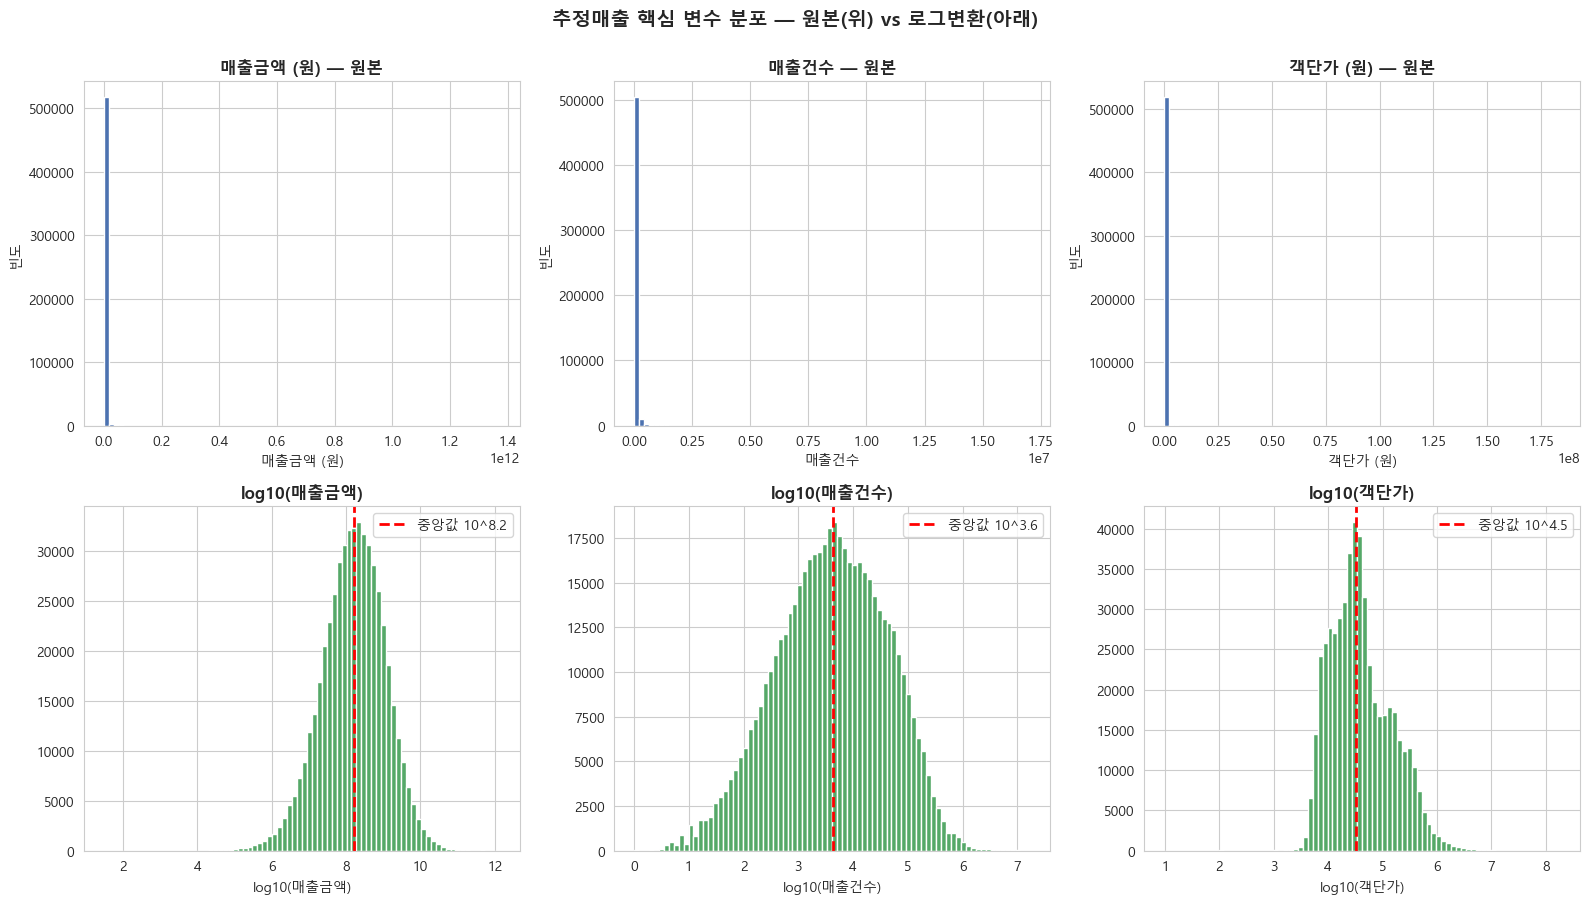

In [42]:
# 분포 시각화: 원본(위) vs 로그변환(아래)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 행 1: 원본
for ax, (col, label) in zip(axes[0], [
    ('당월_매출_금액', '매출금액 (원)'),
    ('당월_매출_건수', '매출건수'),
    ('객단가', '객단가 (원)'),
]):
    ax.hist(sales[col].dropna(), bins=80, color='#4C72B0', edgecolor='white')
    ax.set_title(f'{label} — 원본', fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('빈도')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# 행 2: 로그 변환
for ax, (col, label) in zip(axes[1], [
    ('당월_매출_금액', 'log10(매출금액)'),
    ('당월_매출_건수', 'log10(매출건수)'),
    ('객단가', 'log10(객단가)'),
]):
    log_data = np.log10(sales[col].dropna().clip(lower=1))
    ax.hist(log_data, bins=80, color='#55A868', edgecolor='white')
    ax.axvline(log_data.median(), color='red', linestyle='--', linewidth=2,
               label=f'중앙값 10^{log_data.median():.1f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.legend()

plt.suptitle('추정매출 핵심 변수 분포 — 원본(위) vs 로그변환(아래)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

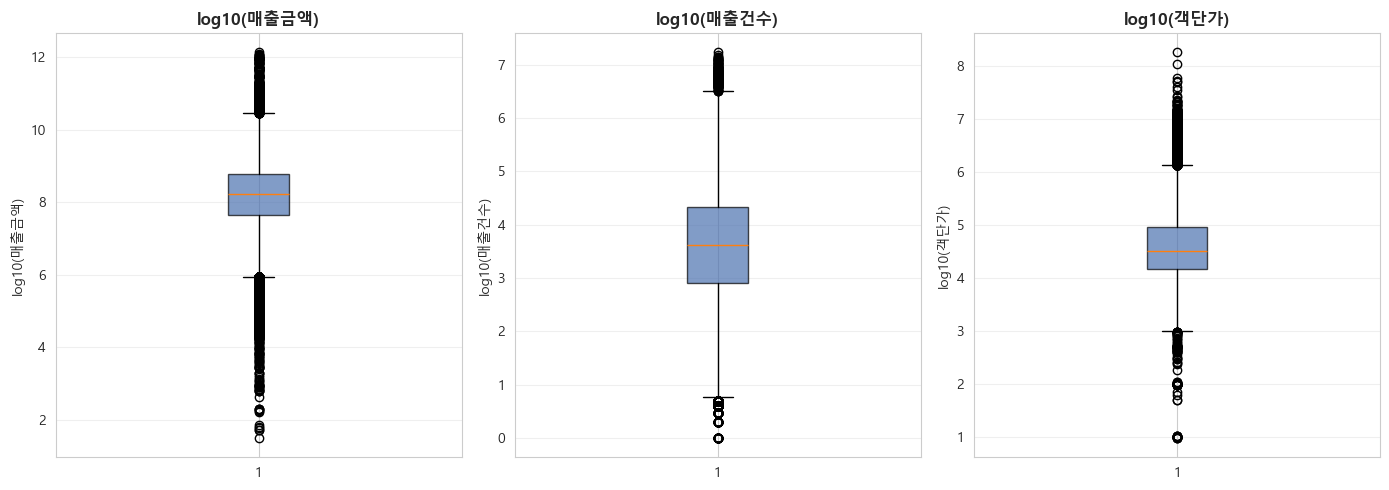

In [43]:
# 박스플롯 (로그 스케일)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (col, label) in zip(axes, [
    ('당월_매출_금액', '매출금액'),
    ('당월_매출_건수', '매출건수'),
    ('객단가', '객단가'),
]):
    log_data = np.log10(sales[col].dropna().clip(lower=1))
    ax.boxplot(log_data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7))
    ax.set_title(f'log10({label})', fontweight='bold')
    ax.set_ylabel(f'log10({label})')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# 왜도 (정규분포 정도) - -0.5~+0.5면 거의 정규
print('로그 변환 후 왜도 (skewness)')
print('기준: -0.5 ~ +0.5 → 정규분포에 가까움\n')
for col in ['당월_매출_금액','당월_매출_건수','객단가']:
    log_d = np.log10(sales[col].dropna().clip(lower=1))
    skew = log_d.skew()
    상태 = '✅ 정규에 가까움' if abs(skew) < 0.5 else '🟡 약간 치우침'
    print(f'  {col}: 왜도={skew:+.2f}  {상태}')

로그 변환 후 왜도 (skewness)
기준: -0.5 ~ +0.5 → 정규분포에 가까움

  당월_매출_금액: 왜도=-0.25  ✅ 정규에 가까움
  당월_매출_건수: 왜도=-0.19  ✅ 정규에 가까움
  객단가: 왜도=+0.56  🟡 약간 치우침


### 💡 Step 2 인사이트
- 원본 분포는 극단적 우편향 (long-tail) → 그대로 못 씀
- **로그 변환** 후 정규분포에 매우 근접 (왜도 절댓값 < 0.5)
- → **상권 발달 점수에서 매출 변수는 `log10(매출)` 후 min-max 정규화 사용**
- 메모: 

---
## 3️⃣ Step 3: 상권 구분별 비교

목표:
- 영역 파일을 merge해서 자치구 정보 결합
- 상권 단위로 매출 집계
- **관광특구 / 발달상권 / 골목상권 / 전통시장** 4가지 그룹 비교
- 프로젝트의 핵심 질문: "골목 vs 일반 상권 불균형" 첫 정량 증거

In [45]:
# 영역 정보 merge
sales_area = sales.merge(
    area[['상권_코드','자치구_코드_명','행정동_코드_명','엑스좌표_값','와이좌표_값']],
    on='상권_코드', how='left'
)
print(f'merge 후: {sales_area.shape}')
print(f'결측 자치구: {sales_area["자치구_코드_명"].isna().sum()}')

merge 후: (519931, 60)
결측 자치구: 0


In [46]:
# 최신 분기로 필터 후 상권 단위 집계
latest = sales_area[sales_area['기준_년분기_코드']==LATEST_QUARTER]

상권집계 = latest.groupby(
    ['상권_코드','상권_코드_명','상권_구분_코드_명','자치구_코드_명']
).agg(
    총매출=('당월_매출_금액','sum'),
    총건수=('당월_매출_건수','sum'),
    업종수=('서비스_업종_코드','nunique'),
).reset_index()

상권집계['객단가'] = 상권집계['총매출'] / 상권집계['총건수']
상권집계['log_매출'] = np.log10(상권집계['총매출'].clip(lower=1))
상권집계['총매출_억'] = (상권집계['총매출']/1e8).round(1)

print(f'분석 대상 상권: {len(상권집계):,}개')
상권집계.head()

분석 대상 상권: 1,565개


,상권_코드,상권_코드_명,상권_구분_코드_명,자치구_코드_명,총매출,총건수,업종수,객단가,log_매출,총매출_억
0,3001491,이태원 관광특구,관광특구,용산구,96748250708,3137664,33,"30,834.48",10.99,967.50
1,3001492,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,537829815743,15760017,53,"34,126.22",11.73,"5,378.30"
2,3001493,동대문패션타운 관광특구,관광특구,중구,151636997858,4447433,39,"34,095.40",11.18,"1,516.40"
3,3001494,종로?청계 관광특구,관광특구,종로구,263865637195,6909787,53,"38,187.23",11.42,"2,638.70"
4,3001495,잠실 관광특구,관광특구,송파구,380932087468,13411055,42,"28,404.33",11.58,"3,809.30"


In [47]:
# 상권 구분별 요약 통계
구분통계 = 상권집계.groupby('상권_구분_코드_명').agg(
    상권수=('상권_코드','count'),
    평균매출=('총매출','mean'),
    중앙매출=('총매출','median'),
    평균객단가=('객단가','mean'),
    평균업종수=('업종수','mean'),
)
구분통계['평균매출_억'] = (구분통계['평균매출']/1e8).round(1)
구분통계['중앙매출_억'] = (구분통계['중앙매출']/1e8).round(1)
구분통계['평균객단가'] = 구분통계['평균객단가'].round(0)
구분통계['평균업종수'] = 구분통계['평균업종수'].round(1)
구분통계 = 구분통계.reindex(['관광특구','발달상권','전통시장','골목상권'])
구분통계[['상권수','평균매출_억','중앙매출_억','평균객단가','평균업종수']]

,상권수,평균매출_억,중앙매출_억,평균객단가,평균업종수
상권_구분_코드_명,,,,,
관광특구,6,"2,570.60","2,077.50","33,071.00",41.30
발달상권,249,599.60,348.40,"38,682.00",29.10
전통시장,280,138.00,46.90,"39,479.00",11.30
골목상권,1030,39.80,19.80,"42,542.00",10.40


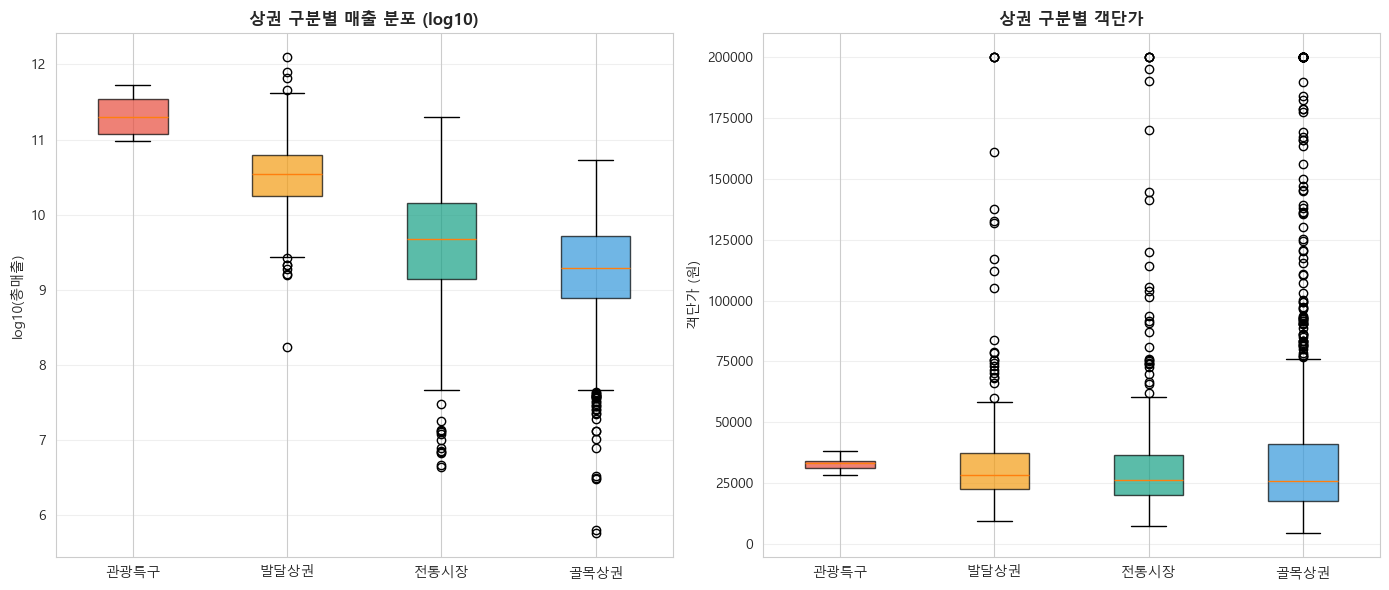

In [48]:
# 박스플롯: 상권 구분별 매출 vs 객단가
순서 = ['관광특구','발달상권','전통시장','골목상권']
colors = ['#E74C3C','#F39C12','#16A085','#3498DB']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) 매출 분포 (로그)
data1 = [상권집계[상권집계['상권_구분_코드_명']==g]['log_매출'].values for g in 순서]
bp1 = axes[0].boxplot(data1, labels=순서, patch_artist=True)
for patch, c in zip(bp1['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0].set_title('상권 구분별 매출 분포 (log10)', fontweight='bold')
axes[0].set_ylabel('log10(총매출)')
axes[0].grid(axis='y', alpha=0.3)

# (2) 객단가 (200,000원 캡 - 이상치 가시성 향상)
data2 = [상권집계[상권집계['상권_구분_코드_명']==g]['객단가'].clip(upper=200000).values for g in 순서]
bp2 = axes[1].boxplot(data2, labels=순서, patch_artist=True)
for patch, c in zip(bp2['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title('상권 구분별 객단가', fontweight='bold')
axes[1].set_ylabel('객단가 (원)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
# 매출 TOP 20 상권
top20 = 상권집계.nlargest(20, '총매출')[
    ['상권_코드_명','상권_구분_코드_명','자치구_코드_명','총매출_억','업종수']
]
top20

,상권_코드_명,상권_구분_코드_명,자치구_코드_명,총매출_억,업종수
1188,노량진역(노량진),발달상권,동작구,"12,616.30",37
1166,가산디지털단지,발달상권,금천구,"8,043.80",51
1075,용산전자상가(용산역),발달상권,용산구,"6,689.90",32
1,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,"5,378.30",53
1266,가락시장,발달상권,송파구,"4,592.10",10
1224,강남역,발달상권,서초구,"4,187.00",49
4,잠실 관광특구,관광특구,송파구,"3,809.30",42
1044,종로3가역,발달상권,종로구,"3,313.20",44
1262,잠실역,발달상권,송파구,"3,219.90",34
3,종로?청계 관광특구,관광특구,종로구,"2,638.70",53


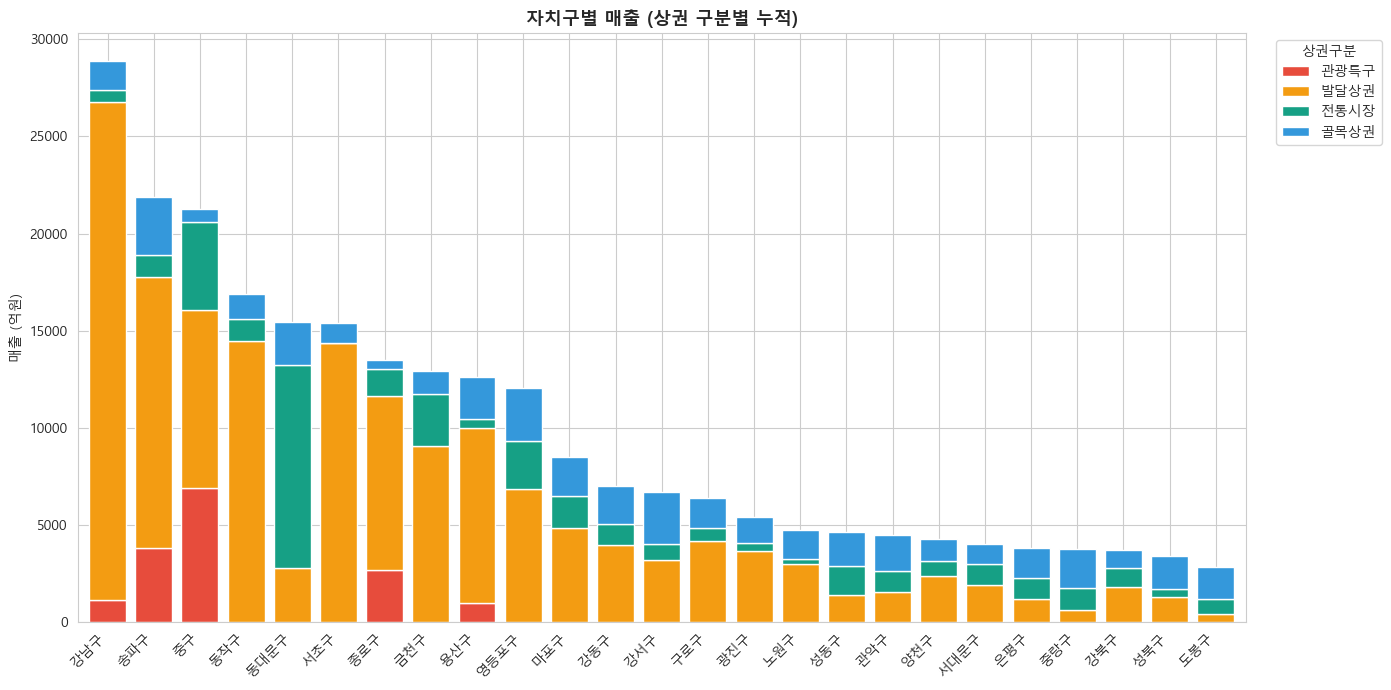

In [50]:
# 자치구별 총매출 + 상권 구분 분포
구별 = 상권집계.groupby(['자치구_코드_명','상권_구분_코드_명'])['총매출'].sum().unstack(fill_value=0)/1e8
구별['합계'] = 구별.sum(axis=1)
구별 = 구별.sort_values('합계', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
구별_plot = 구별.drop('합계', axis=1)
구별_plot = 구별_plot[[c for c in 순서 if c in 구별_plot.columns]]
구별_plot.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.8)
ax.set_title('자치구별 매출 (상권 구분별 누적)', fontweight='bold', fontsize=13)
ax.set_ylabel('매출 (억원)')
ax.set_xlabel('')
ax.legend(title='상권구분', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 💡 Step 3 인사이트
- 관광특구가 평균 매출은 가장 높지만 **상권 수가 6개로 매우 적음** → 영향력 vs 면적 trade-off
- 골목상권 1,000여 개의 매출 분포와 발달상권 분포 비교
- 자치구별 매출 편차 → 어떤 구가 관광 매출 강자인지
- 메모: 

---
## 4️⃣ Step 4: 업종별 매출 패턴

목표:
- 100개 업종 중 매출 상위 업종 식별
- 어떤 업종이 어떤 상권 구분에서 강한지
- "관광객이 무엇을 사는지" 첫 단서

In [51]:
# 업종별 총매출 (최신 분기)
업종집계 = latest.groupby(['서비스_업종_코드','서비스_업종_코드_명']).agg(
    총매출=('당월_매출_금액','sum'),
    총건수=('당월_매출_건수','sum'),
    상권수=('상권_코드','nunique'),
).reset_index()
업종집계['객단가'] = 업종집계['총매출']/업종집계['총건수']
업종집계['매출_억'] = (업종집계['총매출']/1e8).round(1)
업종집계 = 업종집계.sort_values('총매출', ascending=False)
print(f'업종 수: {len(업종집계)}')
업종집계.head(10)

업종 수: 62


,서비스_업종_코드,서비스_업종_코드_명,총매출,총건수,상권수,객단가,매출_억
0,CS100001,한식음식점,3985898301921,97348712,1406,"40,944.54","39,859.00"
40,CS300011,일반의류,2132212624743,29900054,850,"71,311.33","21,322.10"
14,CS200006,일반의원,1787685318222,32891128,518,"54,351.60","17,876.90"
45,CS300018,의약품,1426634468592,58776059,583,"24,272.37","14,266.30"
37,CS300008,수산물판매,1400689731246,21052006,130,"66,534.74","14,006.90"
38,CS300009,청과상,1281305234493,49080474,274,"26,106.21","12,813.10"
39,CS300010,반찬가게,856226080781,34798223,400,"24,605.45","8,562.30"
31,CS300001,슈퍼마켓,849778983467,74225863,888,"11,448.56","8,497.80"
36,CS300007,육류판매,807736979652,14832645,405,"54,456.71","8,077.40"
32,CS300002,편의점,806130121145,110658092,671,"7,284.87","8,061.30"


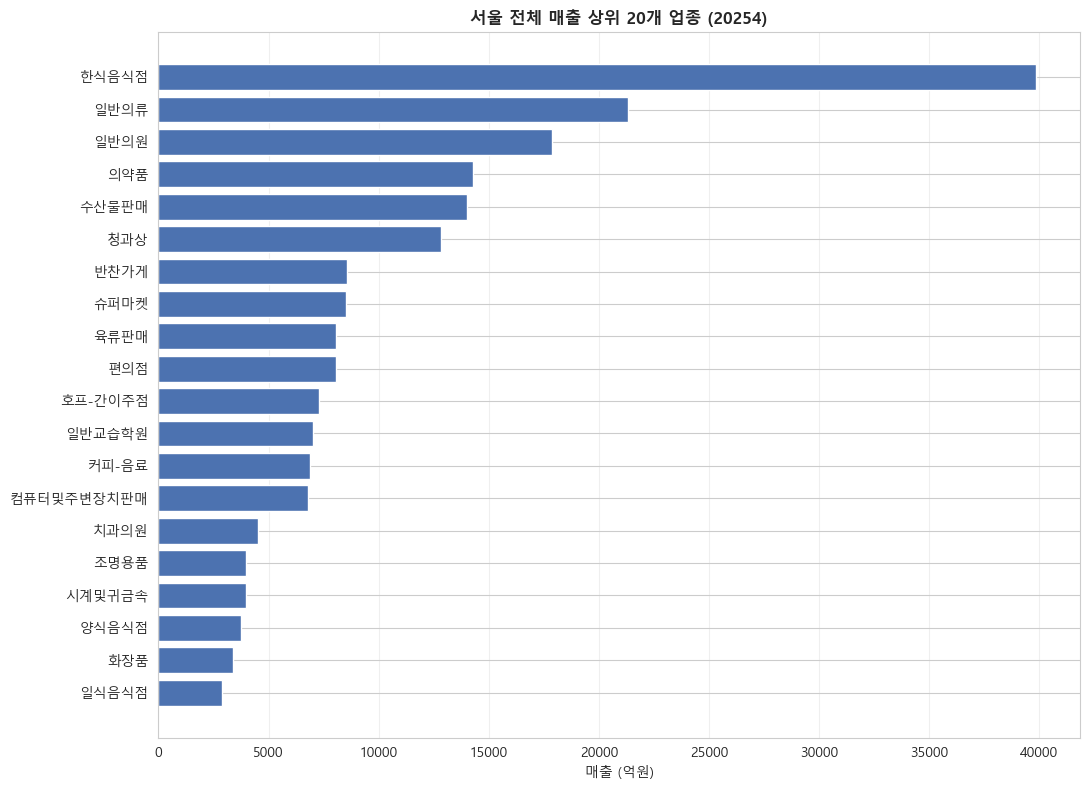

In [52]:
# TOP 20 업종 바차트
top20_업종 = 업종집계.head(20).copy()

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top20_업종['서비스_업종_코드_명'][::-1], top20_업종['매출_억'][::-1], 
        color='#4C72B0', edgecolor='white')
ax.set_xlabel('매출 (억원)')
ax.set_title(f'서울 전체 매출 상위 20개 업종 ({LATEST_QUARTER})', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

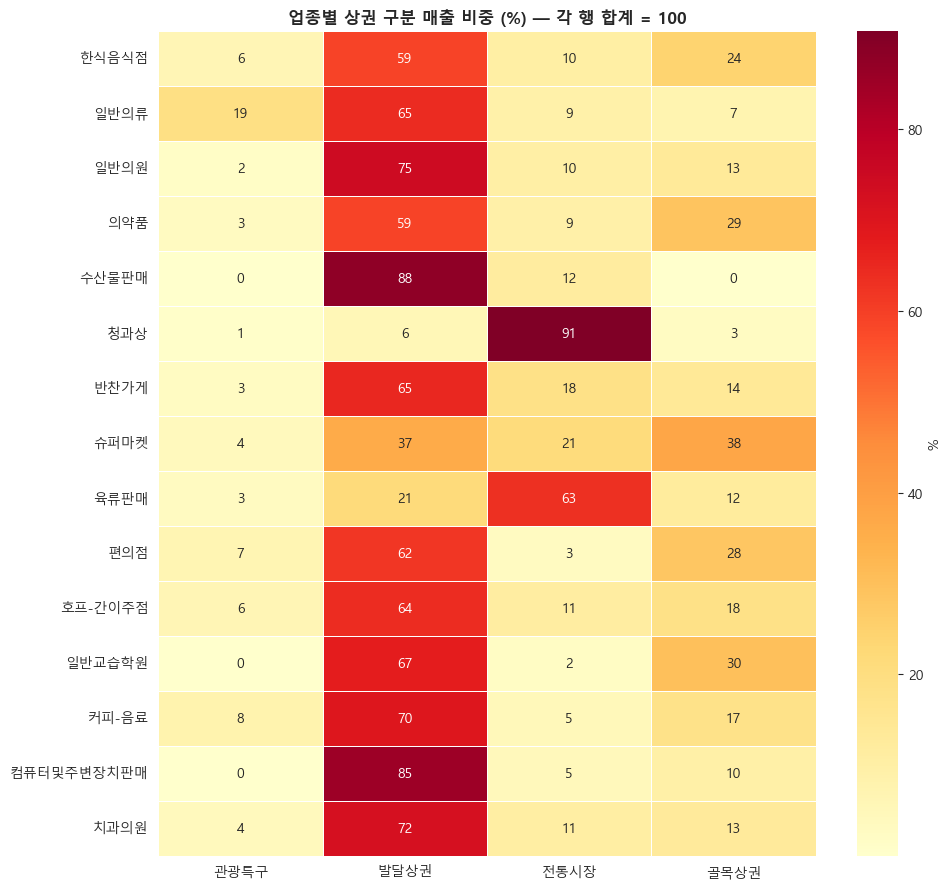

In [53]:
# 업종 × 상권구분 매출 비중 히트맵 (TOP 15 업종)
top15 = 업종집계.head(15)['서비스_업종_코드_명'].tolist()

sub = latest[latest['서비스_업종_코드_명'].isin(top15)]
pivot = sub.pivot_table(
    values='당월_매출_금액',
    index='서비스_업종_코드_명',
    columns='상권_구분_코드_명',
    aggfunc='sum'
).fillna(0)/1e8

# 컬럼 순서 정렬
pivot = pivot[[c for c in 순서 if c in pivot.columns]]

# 각 업종 행을 100%로 정규화
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.reindex(top15)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(pivot_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': '%'}, ax=ax, linewidths=0.5)
ax.set_title('업종별 상권 구분 매출 비중 (%) — 각 행 합계 = 100', 
             fontweight='bold', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [54]:
# 관광특구에서 특히 강한 업종 (관광객 소비 패턴 단서)
관광특구_매출 = latest[latest['상권_구분_코드_명']=='관광특구'].groupby(
    '서비스_업종_코드_명'
)['당월_매출_금액'].sum().sort_values(ascending=False)/1e8

print('🎯 관광특구 매출 TOP 15 업종 (단위: 억원)')
print(관광특구_매출.head(15).round(0))

🎯 관광특구 매출 TOP 15 업종 (단위: 억원)
서비스_업종_코드_명
일반의류      4,045.00
한식음식점     2,513.00
시계및귀금속      697.00
커피-음료       548.00
편의점         534.00
양식음식점       473.00
호프-간이주점     462.00
화장품         450.00
의약품         434.00
조명용품        379.00
슈퍼마켓        356.00
문구          354.00
운동/경기용품     339.00
중식음식점       276.00
일반의원        275.00
Name: 당월_매출_금액, dtype: float64


### 💡 Step 4 인사이트
- 매출 상위 업종은 무엇인가? (예상: 한식, 의류, 슈퍼마켓 등)
- 관광특구에 특화된 업종은? (예상: 화장품, 외국인 면세 관련)
- 골목상권 vs 관광특구의 업종 mix 차이
- 메모: 

---
## 5️⃣ Step 5: 페르소나 분석 (성·연령·시간·요일)

목표:
- 상권 구분별로 누가/언제/어떻게 소비하는지
- 관광 상권은 평일/주말 패턴이 일상 상권과 다를 것
- 페르소나는 발달 점수 산출 후 클러스터링에도 활용 가능

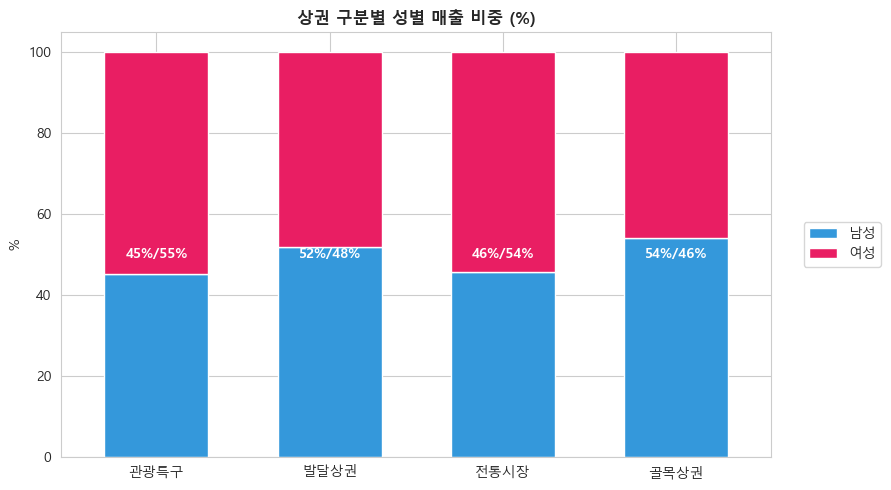

In [55]:
# 5-1. 성별 매출 비중
gender = latest.groupby('상권_구분_코드_명').agg(
    남성=('남성_매출_금액','sum'),
    여성=('여성_매출_금액','sum'),
).reindex(순서)
gender_pct = gender.div(gender.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
gender_pct.plot(kind='bar', stacked=True, ax=ax, 
                color=['#3498DB','#E91E63'], width=0.6)
ax.set_title('상권 구분별 성별 매출 비중 (%)', fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('')
ax.legend(loc='center', bbox_to_anchor=(1.1, 0.5))
plt.xticks(rotation=0)
for i, (idx, row) in enumerate(gender_pct.iterrows()):
    ax.text(i, 50, f'{row["남성"]:.0f}%/{row["여성"]:.0f}%',
            ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

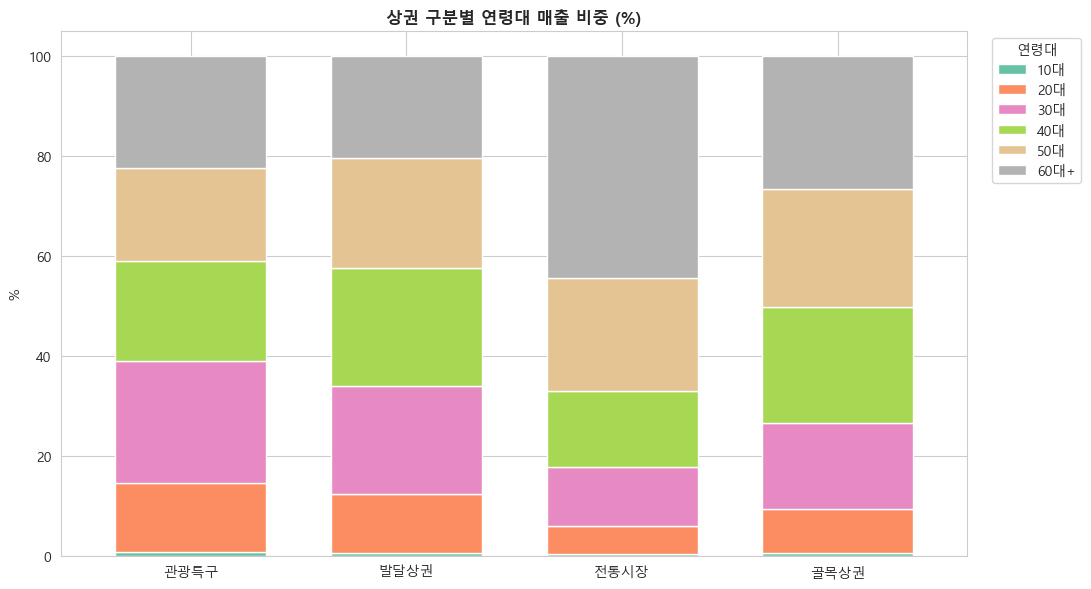


수치 (%)
            10대   20대   30대   40대   50대  60대+
상권_구분_코드_명                                   
관광특구       0.80 13.70 24.40 20.10 18.60 22.40
발달상권       0.50 11.70 21.60 23.70 22.10 20.30
전통시장       0.30  5.60 11.90 15.10 22.60 44.50
골목상권       0.50  9.00 17.00 23.30 23.50 26.70


In [56]:
# 5-2. 연령대별 매출 비중
연령컬럼 = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
        '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
연령라벨 = ['10대','20대','30대','40대','50대','60대+']

age_data = latest.groupby('상권_구분_코드_명')[연령컬럼].sum().reindex(순서)
age_data.columns = 연령라벨
age_pct = age_data.div(age_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
age_pct.plot(kind='bar', stacked=True, ax=ax, 
             colormap='Set2', width=0.7, edgecolor='white')
ax.set_title('상권 구분별 연령대 매출 비중 (%)', fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('')
ax.legend(title='연령대', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\n수치 (%)')
print(age_pct.round(1))

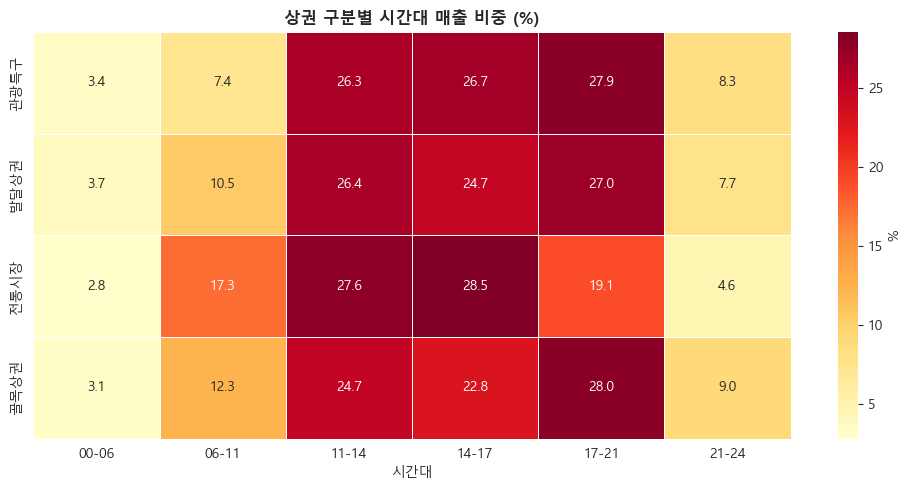

In [57]:
# 5-3. 시간대별 매출 비중 (히트맵)
시간컬럼 = ['시간대_00~06_매출_금액','시간대_06~11_매출_금액','시간대_11~14_매출_금액',
        '시간대_14~17_매출_금액','시간대_17~21_매출_금액','시간대_21~24_매출_금액']
시간라벨 = ['00-06','06-11','11-14','14-17','17-21','21-24']

time_data = latest.groupby('상권_구분_코드_명')[시간컬럼].sum().reindex(순서)
time_data.columns = 시간라벨
time_pct = time_data.div(time_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(time_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '%'}, ax=ax, linewidths=0.5)
ax.set_title('상권 구분별 시간대 매출 비중 (%)', fontweight='bold')
ax.set_xlabel('시간대')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

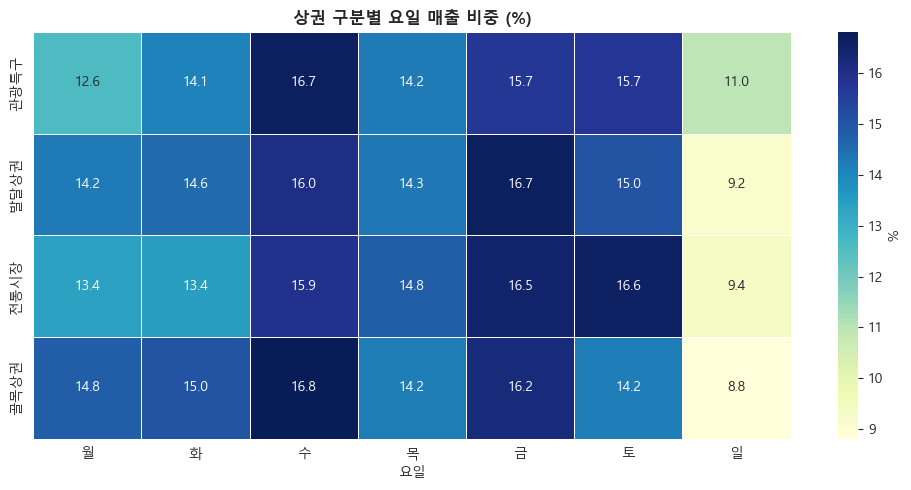


🎯 주말(토+일) 매출 비중
상권_구분_코드_명
관광특구   26.70
발달상권   24.20
전통시장   26.00
골목상권   23.00
dtype: float64

→ 기준: 일상적 분포는 ~28.6% (1/7×2), 관광 상권은 더 높을 것


In [58]:
# 5-4. 요일별 매출 비중 (히트맵)
요일컬럼 = ['월요일_매출_금액','화요일_매출_금액','수요일_매출_금액','목요일_매출_금액',
        '금요일_매출_금액','토요일_매출_금액','일요일_매출_금액']
요일라벨 = ['월','화','수','목','금','토','일']

day_data = latest.groupby('상권_구분_코드_명')[요일컬럼].sum().reindex(순서)
day_data.columns = 요일라벨
day_pct = day_data.div(day_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(day_pct, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': '%'}, ax=ax, linewidths=0.5)
ax.set_title('상권 구분별 요일 매출 비중 (%)', fontweight='bold')
ax.set_xlabel('요일')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# 주말 비중 (토+일)
주말비중 = (day_pct['토'] + day_pct['일']).round(1)
print('\n🎯 주말(토+일) 매출 비중')
print(주말비중)
print('\n→ 기준: 일상적 분포는 ~28.6% (1/7×2), 관광 상권은 더 높을 것')

### 💡 Step 5 인사이트
- 관광특구는 주말 비중이 골목상권보다 얼마나 높은가?
- 어떤 상권이 어느 연령대에 강한가?
- 시간대 패턴: 관광 vs 직장가 vs 주거지
- 메모: 

---
## 6️⃣ Step 6: 시계열 트렌드 (2020~2025)

목표:
- 분기별 매출 추이
- 코로나 충격(2020~2021) → 회복(2022~)
- 상권 구분별 회복 속도 차이

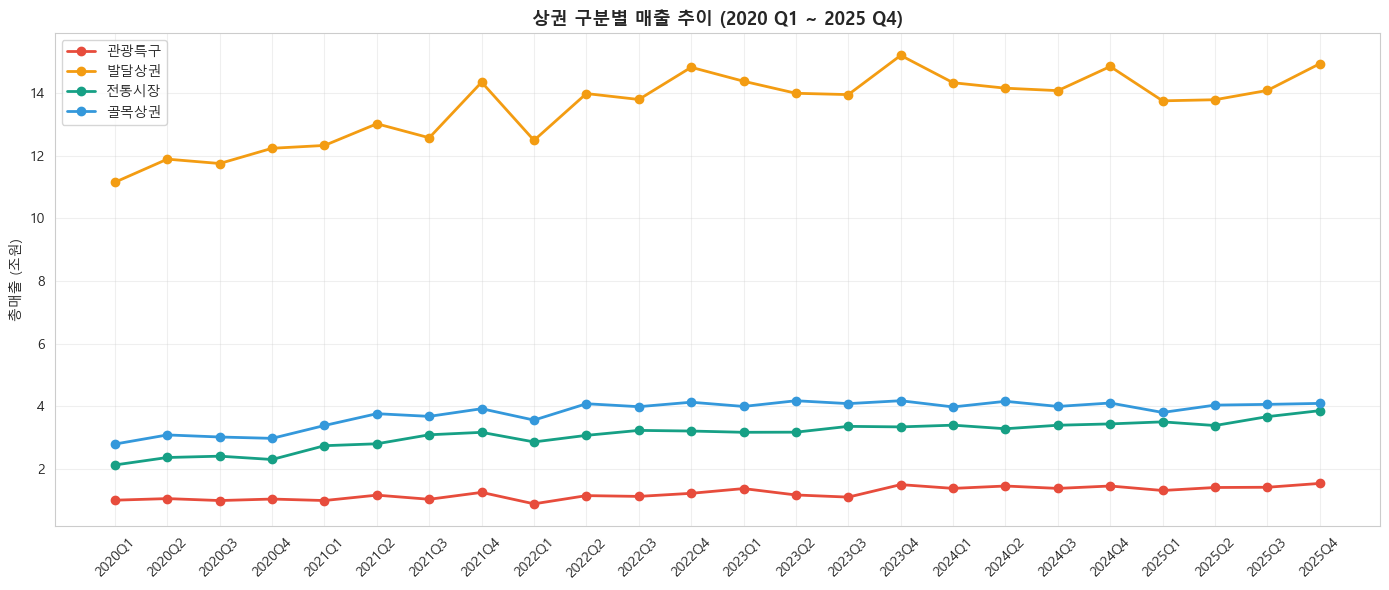

In [59]:
# 분기별 상권 구분별 총매출
trend = sales_area.groupby(['기준_년분기_코드','상권_구분_코드_명'])['당월_매출_금액'].sum().reset_index()
trend['매출_조'] = trend['당월_매출_금액']/1e12

# 라벨용 (예: 20221 → 2022Q1)
def to_label(q):
    return f'{q//10}Q{q%10}'
trend['분기라벨'] = trend['기준_년분기_코드'].apply(to_label)

fig, ax = plt.subplots(figsize=(14, 6))
for grp, color in zip(순서, colors):
    sub = trend[trend['상권_구분_코드_명']==grp].sort_values('기준_년분기_코드')
    ax.plot(sub['분기라벨'], sub['매출_조'], 
            marker='o', label=grp, linewidth=2, color=color)
ax.set_title('상권 구분별 매출 추이 (2020 Q1 ~ 2025 Q4)', fontweight='bold', fontsize=13)
ax.set_ylabel('총매출 (조원)')
ax.set_xlabel('')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
# 코로나 전후 회복률 (2020 Q1 → 2025 Q4)
period = sales_area[sales_area['기준_년분기_코드'].isin([20201, 20254])].groupby(
    ['기준_년분기_코드','상권_구분_코드_명']
)['당월_매출_금액'].sum().unstack(0)
period.columns = ['2020Q1','2025Q4']
period['성장률(%)'] = ((period['2025Q4']/period['2020Q1']-1)*100).round(1)
period['2020Q1_조'] = (period['2020Q1']/1e12).round(2)
period['2025Q4_조'] = (period['2025Q4']/1e12).round(2)
period = period.reindex(순서)
period[['2020Q1_조','2025Q4_조','성장률(%)']]

,2020Q1_조,2025Q4_조,성장률(%)
상권_구분_코드_명,,,
관광특구,1.01,1.54,53.10
발달상권,11.15,14.93,33.90
전통시장,2.13,3.86,81.30
골목상권,2.80,4.09,46.40


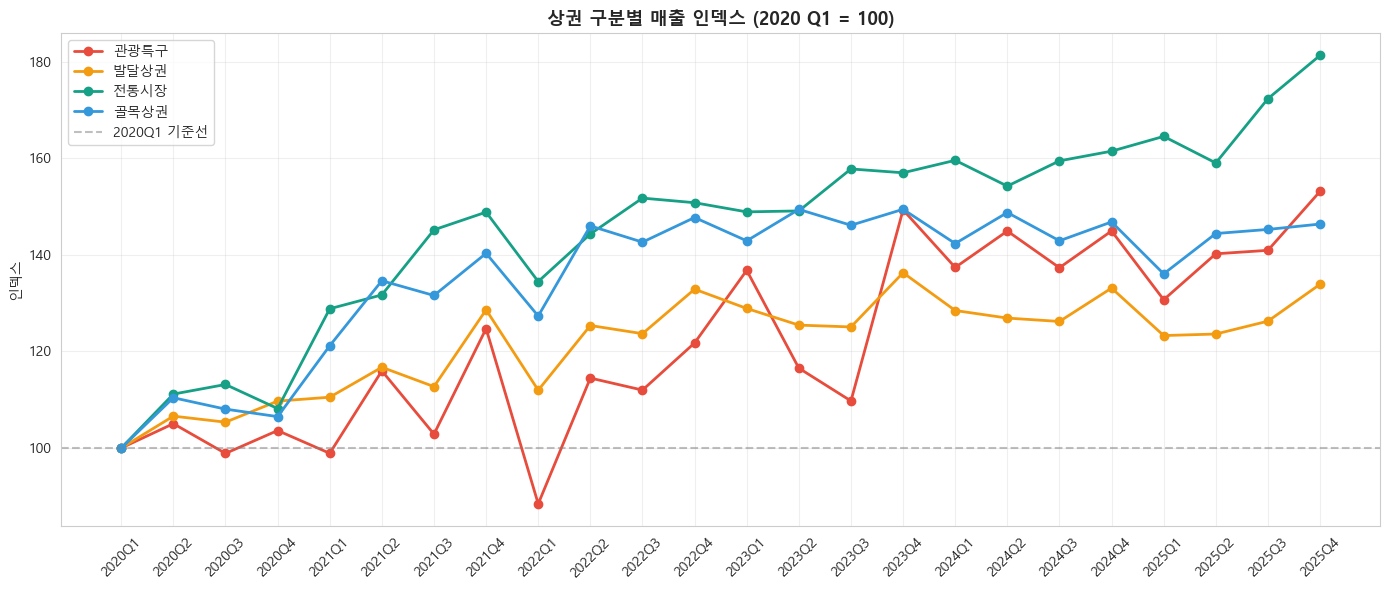

In [61]:
# 분기별 인덱스 (2020Q1 = 100) - 회복 속도 비교용
base = trend[trend['기준_년분기_코드']==20201].set_index('상권_구분_코드_명')['당월_매출_금액']
trend['인덱스'] = trend.apply(
    lambda r: r['당월_매출_금액']/base[r['상권_구분_코드_명']]*100, axis=1
)

fig, ax = plt.subplots(figsize=(14, 6))
for grp, color in zip(순서, colors):
    sub = trend[trend['상권_구분_코드_명']==grp].sort_values('기준_년분기_코드')
    ax.plot(sub['분기라벨'], sub['인덱스'], 
            marker='o', label=grp, linewidth=2, color=color)
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='2020Q1 기준선')
ax.set_title('상권 구분별 매출 인덱스 (2020 Q1 = 100)', fontweight='bold', fontsize=13)
ax.set_ylabel('인덱스')
ax.set_xlabel('')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
# 연도별 총매출 (분기별 합산을 연 단위로)
sales_area['연도'] = sales_area['기준_년분기_코드']//10
연도별 = sales_area.groupby(['연도','상권_구분_코드_명'])['당월_매출_금액'].sum().unstack()/1e12
연도별 = 연도별[순서]
연도별.round(2)

상권_구분_코드_명,관광특구,발달상권,전통시장,골목상권
연도,,,,
2020,4.10,47.01,9.22,11.89
2021,4.46,52.25,11.82,14.76
2022,4.40,55.07,12.39,15.77
2023,5.16,57.50,13.06,16.44
2024,5.69,57.39,13.52,16.25
2025,5.69,56.53,14.43,16.00


### 💡 Step 6 인사이트
- 관광특구는 코로나 충격이 가장 컸을 것 (외국인 입국 막힘)
- 2022~2023년 회복 시작, 2024~2025년 정상화 추세 예상
- 골목상권은 상대적으로 안정적이었을 가능성 (지역 주민 수요)
- 발달상권은 직장가 중심 → 재택근무 영향 가능
- 메모: 